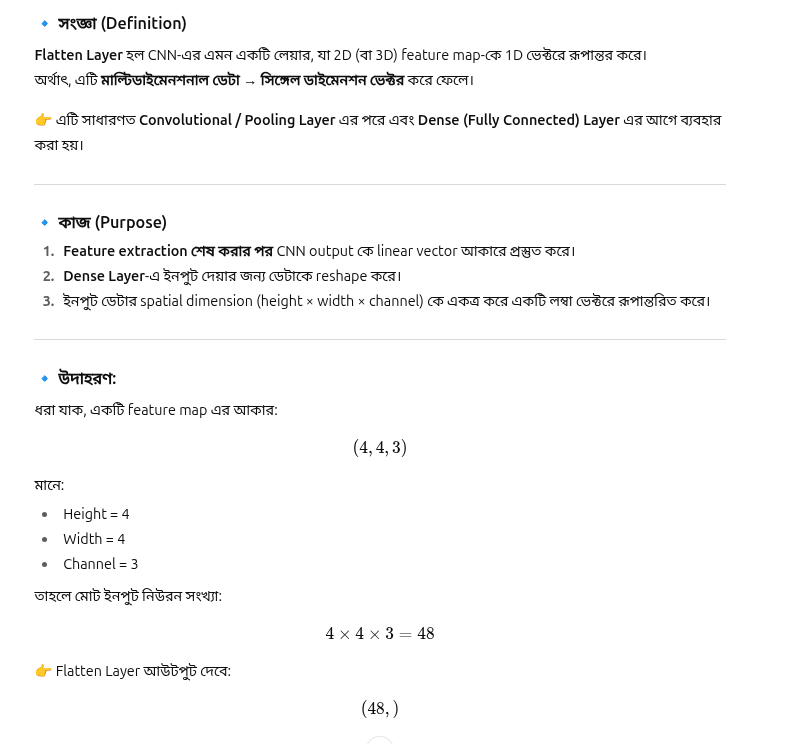

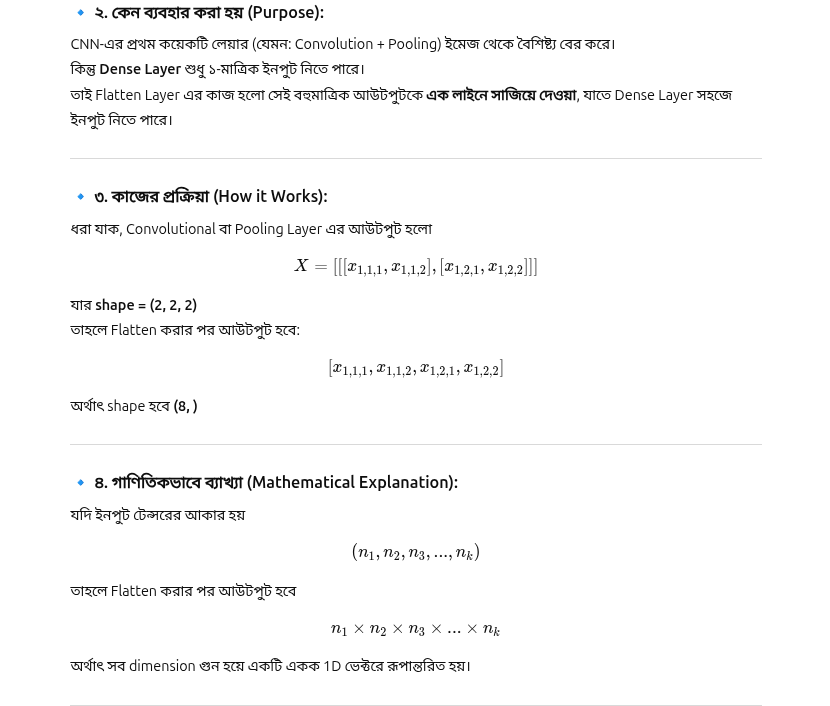

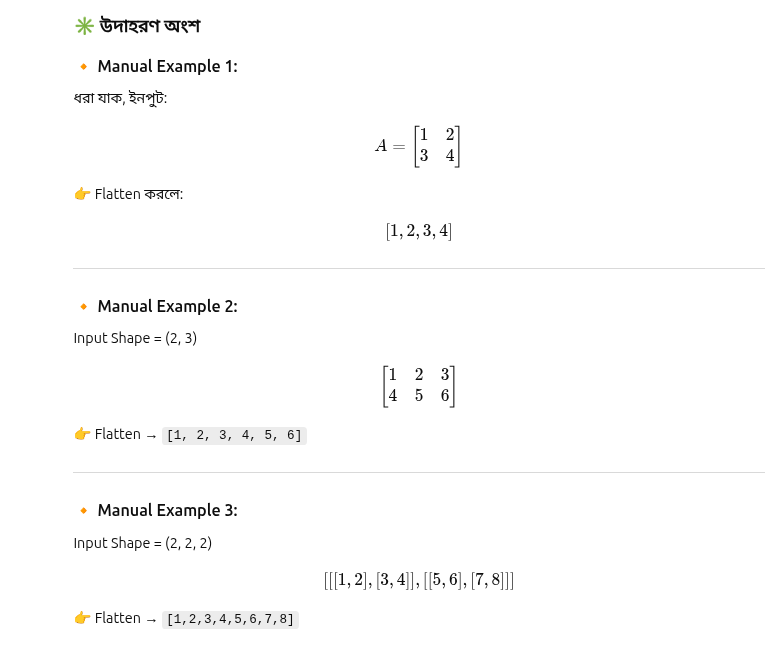

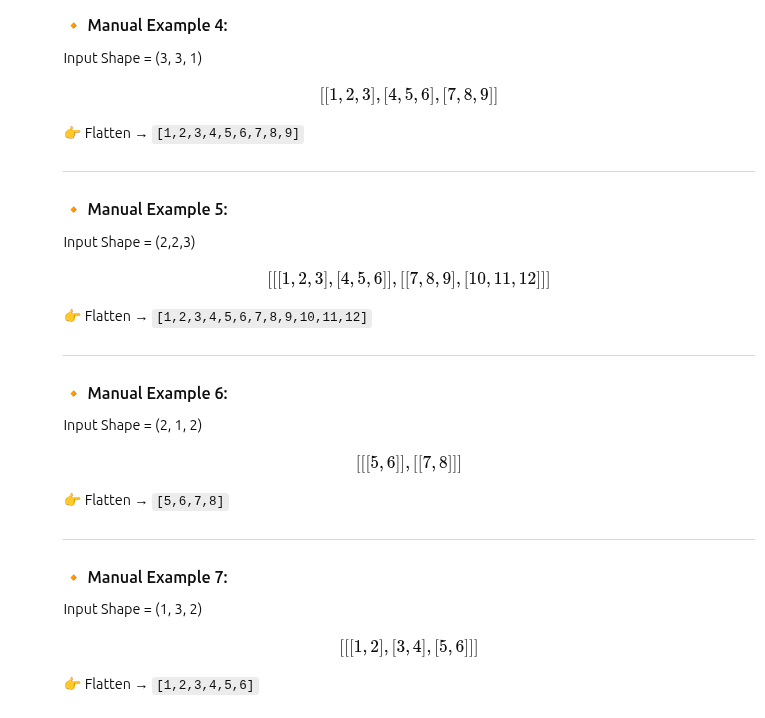

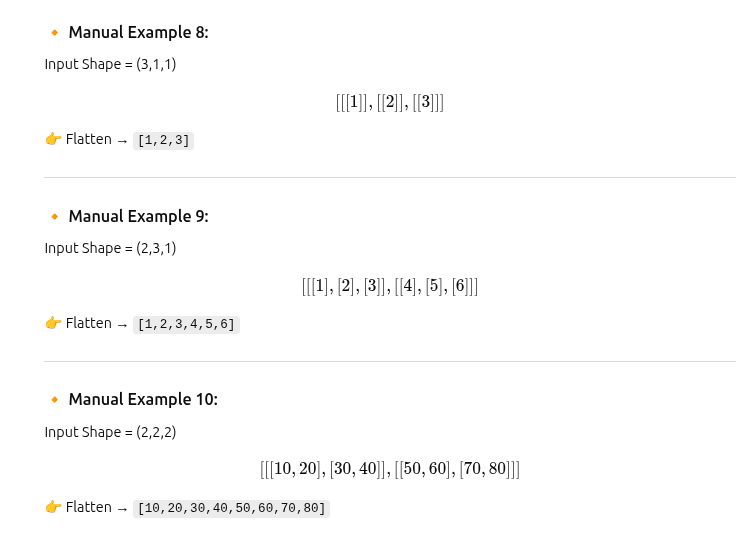

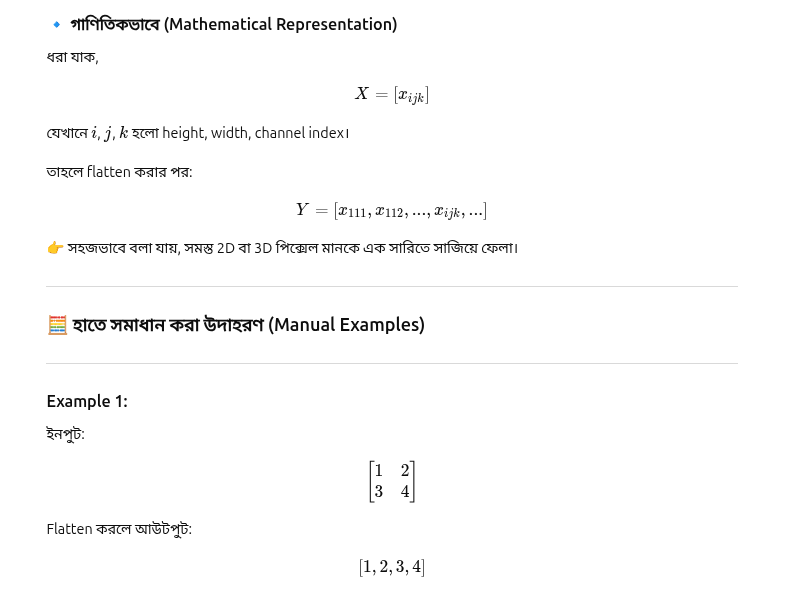

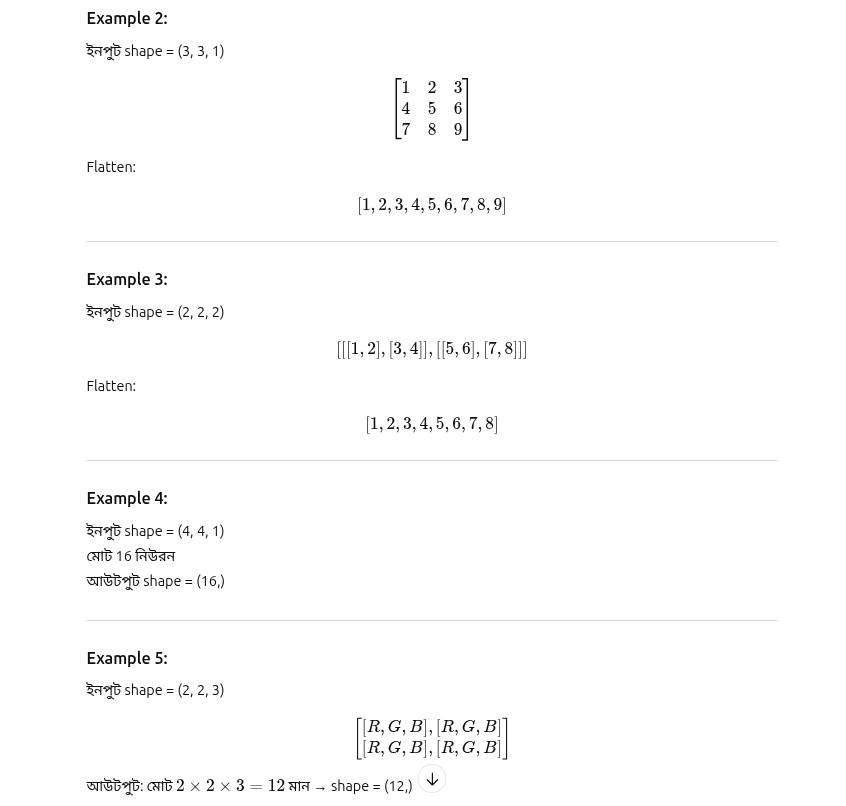

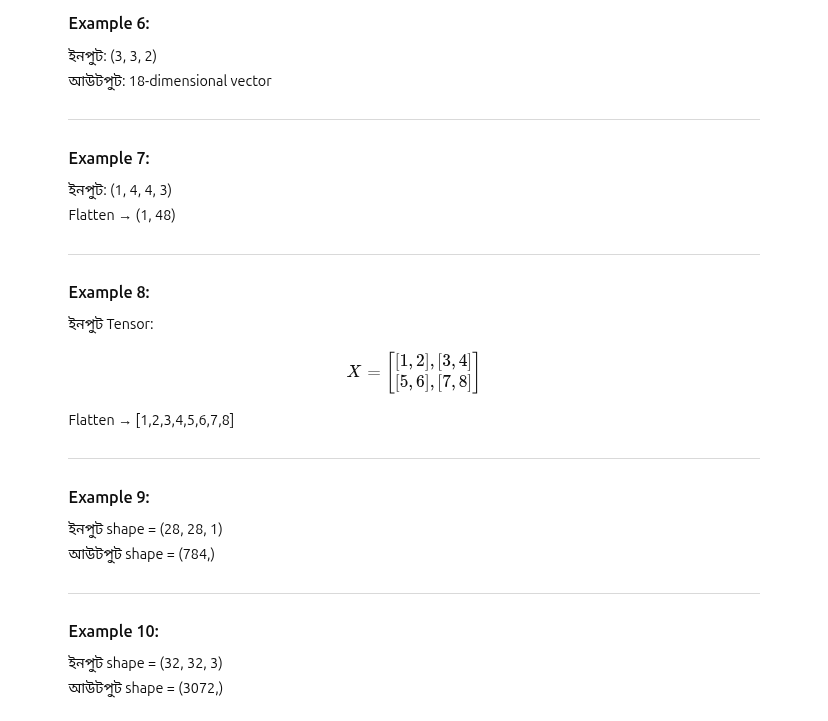

In [1]:
# Code 1: Basic Flatten Layer
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(4, 4, 1)),    # ইনপুট লেয়ার: 4x4 ইমেজ
    layers.Flatten()                  # 2D ডেটা → 1D ভেক্টরে রূপান্তর
])
model.summary()

2025-10-21 23:19:18.470828: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-21 23:19:18.478730: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-21 23:19:18.553760: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-21 23:19:18.625531: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761067158.699442    8028 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761067158.72

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 16)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [2]:
# Code 2: With Dense Layer
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),   # MNIST ইমেজ
    layers.Flatten(),                  # ফ্ল্যাটেন করে Dense লেয়ারে পাঠানো
    layers.Dense(128, activation='relu')
])
model.summary()

W0000 00:00:1761067195.230428    8028 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,480 (392.50 KB)

 Trainable params: 100,480 (392.50 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Code 3: Show Output Shape
import tensorflow as tf

x = tf.random.normal((1, 4, 4, 3))  # ইনপুট টেনসর
flat = tf.keras.layers.Flatten()(x) # ফ্ল্যাটেন অপারেশন
print(flat.shape)                   # আউটপুট: (1, 48)

(1, 48)


In [4]:
# Code 4: Custom Model
inp = layers.Input(shape=(2, 2, 2))        # ইনপুট
flat = layers.Flatten()(inp)               # ফ্ল্যাটেন
out = layers.Dense(4, activation='relu')(flat)
model = models.Model(inputs=inp, outputs=out)

In [5]:
# Code 5: Example with Pooling
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten()  # 2D ম্যাপ → 1D ভেক্টর
])
model.summary()

/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3600)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 448 (1.75 KB)

 Trainable params: 448 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Code 6: Manual Flatten Tensor
import tensorflow as tf

x = tf.constant([[ [1,2], [3,4] ], [ [5,6], [7,8] ]])
flat = tf.reshape(x, (-1,))   # tf.reshape দিয়ে Flatten
print(flat.numpy())           # [1 2 3 4 5 6 7 8]

[1 2 3 4 5 6 7 8]


In [7]:
# Code 7: Using Flatten Layer Standalone
flatten_layer = tf.keras.layers.Flatten()
x = tf.random.uniform((1, 3, 3, 1))
y = flatten_layer(x)
print(y.shape)  # (1, 9)

(1, 9)


In [8]:
# Code 8: Multi-channel Flatten
x = tf.random.normal((1, 2, 2, 3))   # RGB feature map
flat = tf.keras.layers.Flatten()(x)
print(flat.shape)                    # (1, 12)

(1, 12)


In [9]:
# Code 9: Sequential Model (Simple)
model = models.Sequential([
    layers.Conv2D(8, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
model.summary()

/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,170 (211.60 KB)

 Trainable params: 54,170 (211.60 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Code 10: Flatten with Batch Input
x = tf.random.normal((10, 28, 28, 1))  # 10টি ইমেজ
flat = tf.keras.layers.Flatten()(x)
print(flat.shape)  # (10, 784)

(10, 784)


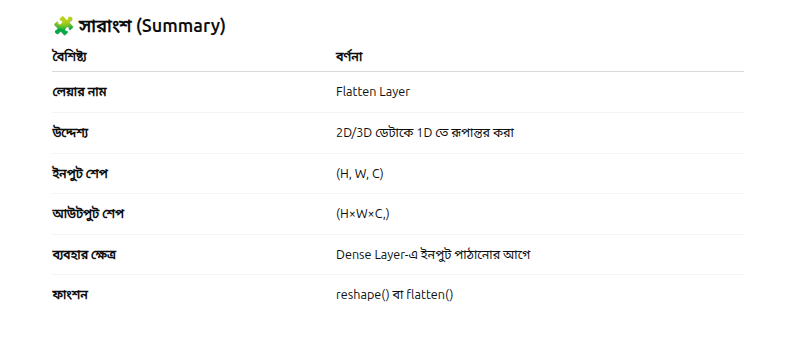

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# একটি Sequential মডেল তৈরি করা হচ্ছে
model = models.Sequential()

# 1️⃣ ইনপুট হিসেবে 2x2x3 আকারের টেন্সর দেওয়া
model.add(layers.Input(shape=(2, 2, 3)))  # ইনপুট 3D টেন্সর

# 2️⃣ Flatten লেয়ার যোগ করা
model.add(layers.Flatten())  # 2D/3D টেন্সরকে 1D তে রূপান্তর করবে

# 3️⃣ মডেলের সারাংশ দেখা
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 12)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

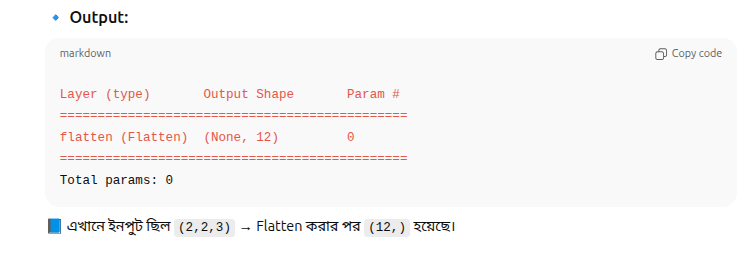

In [12]:
# Example 2: Custom Flatten Operation
import tensorflow as tf

# একটি টেন্সর তৈরি করা হচ্ছে (2x2x2)
x = tf.constant([[[1,2],[3,4]],
                 [[5,6],[7,8]]])

# Flatten করা হচ্ছে
flattened = tf.reshape(x, [-1])  # -1 মানে একমাত্রিক করা
print(flattened.numpy())  # আউটপুট দেখাবে

[1 2 3 4 5 6 7 8]


In [13]:
# Example 3: Flatten Layer সহ ছোট CNN
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),  # ফিচার এক্সট্রাকশন
    layers.MaxPooling2D((2,2)),  # ডাউনস্যাম্পলিং
    layers.Flatten(),  # আউটপুট ফ্ল্যাট করা
    layers.Dense(64, activation='relu'),  # Fully Connected Layer
    layers.Dense(10, activation='softmax')  # আউটপুট লেয়ার
])

model.summary()

/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

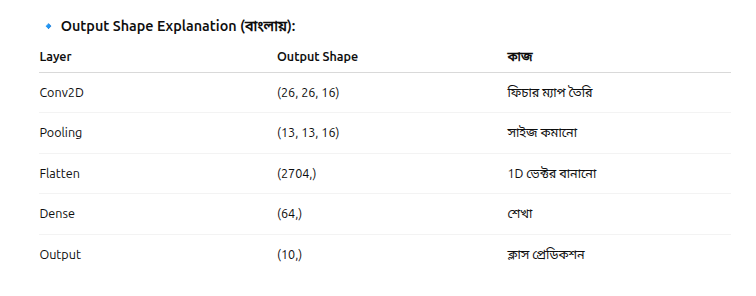

In [14]:
# Example 4: Flatten Shape Check
import tensorflow as tf
input_data = tf.random.normal([1, 4, 4, 3])  # 4x4 RGB ইমেজ
flat = layers.Flatten()(input_data)
print(flat.shape)

(1, 48)


কারণ: 4×4×3 = 48

In [15]:
# Example 5: Custom Layer Shape
x = tf.random.normal([2, 2, 2, 2])
flat_x = layers.Flatten()(x)
print(flat_x.shape)

(2, 8)


এখানে প্রতি স্যাম্পলে 8টি মান → (2×2×2=8)